## A UTFVI-Based Look at Urban Heat: Case Study of Bursa City: Part 2

### Ecological Evaluation for Bursa City

The Urban Thermal Field Variance Index (UTFVI) is a highly useful index for assessing the Urban Heat Island (UHI) phenomenon and evaluating the ecological condition of a given area.
UTFVI values serve as a quantitative basis for qualitatively labeling the severity of UHI effects and the corresponding ecological evaluation of a region, as shown in the table below.

| UTFVI Range           | UHI Phenomenon      | Ecological Evaluation |
|-----------------------|---------------------|-----------------------|
| < 0                   | None                | Excellent             |
| 0 – 0.0049            | Weak                | Good                  |
| 0.005 – 0.0099        | Middle              | Normal                |
| 0.010 – 0.0149        | Strong              | Bad                   |
| 0.015 – 0.0199        | Stronger            | Worse                 |
| ≥ 0.020               | Strongest           | Worst                 |

The lower the UTFVI value in a specific area, the weaker the Urban Heat Island (UHI) phenomenon, leading to an excellent ecological evaluation. This indicates that the area provides a more suitable environment for living organisms. In contrast, higher UTFVI values indicate stronger UHI effects, resulting in uncomfortable living conditions due to increased heat stress and potential heatwaves.

In [1]:
# Import standard python packages
import sys
import subprocess

# Ask GRASS where its Python packages are and add them to the path
grass_call = "grass84"
sys.path.append(
    subprocess.check_output([grass_call, "--config", "python_path"], text=True, shell=True).strip()
)

# Import the GRASS python packages and other packages that we need
import grass.script as gs
import grass.jupyter as gj
from io import StringIO
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Launch a GRASS session
gj.init(r"C:\Users\DELL\Documents\grassdata\bursa_uhi_analysis\PROJECT");

In [3]:
# Define the region based on area
gs.parse_command("g.region", vector="bursa_city", res=30, flags='pg')

{'projection': '1',
 'zone': '35',
 'n': '4464682.82691508',
 's': '4447711.51204576',
 'w': '653245.52841569',
 'e': '689954.5640709',
 'nsres': '29.98465525',
 'ewres': '29.9910422',
 'rows': '566',
 'cols': '1224',
 'cells': '692784'}

In [4]:
# Rasterize district's polygon
gs.run_command("v.to.rast",
               input="bursa_district",
               output="bursa_district",
               use="cat",  # Uses the internal category number (unique per polygon)
               overwrite=True)

In [5]:
# Get vector attributes
attributes = gs.read_command("v.db.select",
                             map="bursa_district",
                             columns="cat,NAME",
                             separator="comma",
                             format="csv")
df_names = pd.read_csv(StringIO(attributes))
df_names

,cat,NAME
0,1,Yildirim
1,2,Gursu
2,3,Gemlik
3,4,Osmangazi
4,5,Mudanya
5,6,Nilufer
6,7,Kestel


##### Seasonal variations in average Land Surface Temperature (LST) across the districts of Bursa City

Let’s extract the average Land Surface Temperature (LST) values for each district in two different seasons—winter and summer—to deepen our understanding of UTFVI, as LST and UTFVI are closely correlated.

In [6]:
# LST zonal stats (Winter)
lst_stats_winter = gs.read_command("r.univar",
                                   flags="t",
                                   map="lst_winter_2025",
                                   zones="bursa_district",
                                   separator="comma")
df_lst_stats_winter = pd.read_csv(StringIO(lst_stats_winter))

# LST zonal stats (Summer)
lst_stats_summer = gs.read_command("r.univar",
                                   flags="t",
                                   map="lst_summer_2025",
                                   zones="bursa_district",
                                   separator="comma")
df_lst_stats_summer = pd.read_csv(StringIO(lst_stats_summer))

# District names (attribute table)
attributes_winter = gs.read_command("v.db.select",
                                    map="bursa_district",
                                    columns="cat,NAME",
                                    separator="comma",
                                    format="csv")
df_names_winter = pd.read_csv(StringIO(attributes_winter))

# Merge LST stats (Winter) with district names
df_lst_final_winter = pd.merge(df_lst_stats_winter,
                               df_names_winter,
                               left_on="zone",
                               right_on="cat",
                               how="left")

# Merge LST stats (Summer) with district names (optional)
df_lst_final_summer = pd.merge(df_lst_stats_summer,
                               df_names_winter,
                               left_on="zone",
                               right_on="cat",
                               how="left")

In [7]:
# LST table for winter
df_lst_final_winter_renamed = df_lst_final_winter[["cat", "NAME", "mean"]].rename(
    columns={
        "cat": "ID",
        "NAME": "District",
        "mean": "Avg_LST_Winter_2025"
    }
)

# LST table for summer
df_lst_final_summer_renamed = df_lst_final_summer[["cat", "NAME", "mean"]].rename(
    columns={
        "cat": "ID",
        "NAME": "District",
        "mean": "Avg_LST_Summer_2025"
    }
)

In [8]:
# LST table visualization
df_lsts_combined = pd.merge(df_lst_final_winter_renamed,
                            df_lst_final_summer_renamed[["ID", "Avg_LST_Summer_2025"]],
                            on="ID")

print(df_lsts_combined)

   ID   District  Avg_LST_Winter_2025  Avg_LST_Summer_2025
0   1   Yildirim             9.005310            36.483562
1   2      Gursu             9.962243            34.297151
2   3     Gemlik             8.366951            29.535277
3   4  Osmangazi             9.704495            35.694113
4   5    Mudanya            10.369206            36.085501
5   6    Nilufer            10.098738            37.041408
6   7     Kestel             7.974934            32.578061


ST values in winter are generally not a major concern. According to the LST Winter table, the highest average land surface temperature is observed in Mudanya district at approximately 10.37 °C, followed by Nilüfer at 10.1 °C. However, in winter, even these surface temperatures remain relatively low, which is ecologically favorable for human habitation.

The main focus of this analysis is the variation of LST values during the summer season. In the summer of 2025, Bursa City exhibited significant variation in high land surface temperatures, with Nilüfer emerging as the most severely affected district (37.05 °C). This is largely attributed to the extensive built-up areas in Nilüfer, as it is the most industrialized district in Bursa and home to numerous manufacturing factories.

Overall, not only built-up areas contribute to higher LST values—barren lands scattered around the suburban regions of Bursa City also play a significant role in intensifying surface heat.

Below is the graphic to intuitively understand more about the variation of land surface temperature across Bursa City's district.

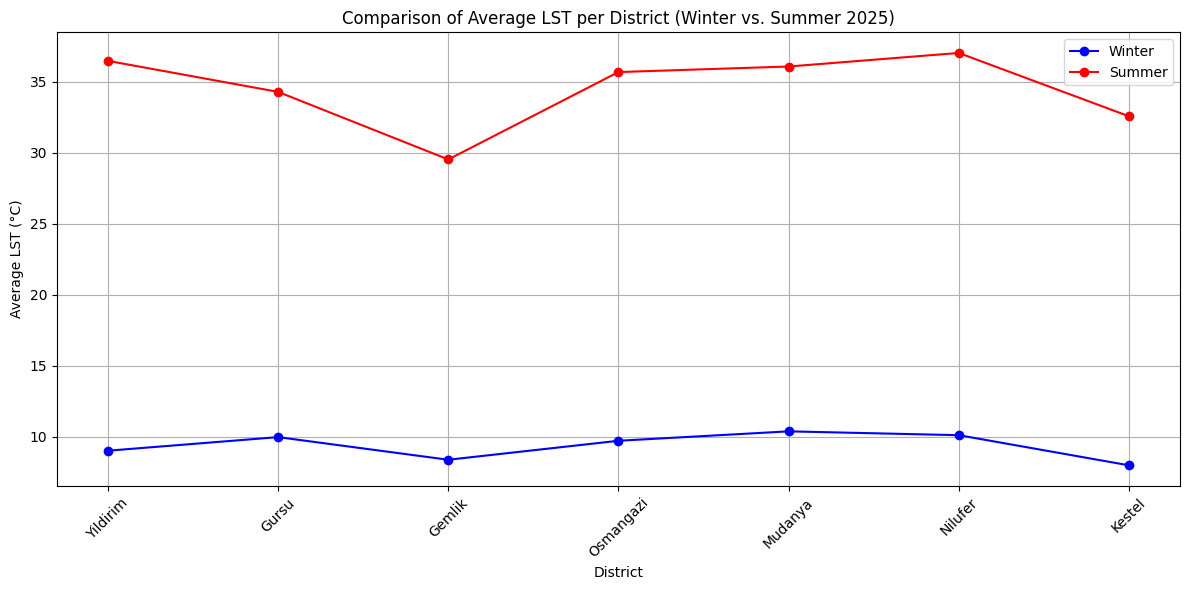

In [65]:
# Line plot
plt.figure(figsize=(12, 6))
plt.plot(df_lsts_combined["District"], df_lsts_combined["Avg_LST_Winter_2025"], 
         marker='o', label="Winter", color='blue')
plt.plot(df_lsts_combined["District"], df_lsts_combined["Avg_LST_Summer_2025"], 
         marker='o', label="Summer", color='red')

plt.xticks(rotation=45)
plt.xlabel("District")
plt.ylabel("Average LST (°C)")
plt.title("Comparison of Average LST per District (Winter vs. Summer 2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The differences in Land Surface Temperature (LST) between winter and summer are clearly evident in the graphic above, with summer showing significantly higher average LST values compared to winter. This variation can be attributed to several key factors:
- The shorter duration of solar radiation in winter reduces the accumulation of heat energy on the Earth’s surface. In contrast, the longer daylight hours during summer lead to higher heat accumulation.
- Lower air temperatures in winter limit the conduction of heat from the atmosphere to the ground surface.
- During winter, the surface of Bursa City tends to be more humid and is sometimes covered by a thin layer of ice or snow. This creates areas with high albedo values, causing a larger portion of incoming solar radiation to be reflected rather than absorbed, thus lowering surface temperatures. The opposite condition typically occurs in summer.

##### UTFVI hotspots across Bursa City

Let’s visualize the UTFVI hotspots spatially using the UTFVI maps we have created for both winter and summer. Pay attention to the differences in the distribution of high UTFVI zones between the two seasons.

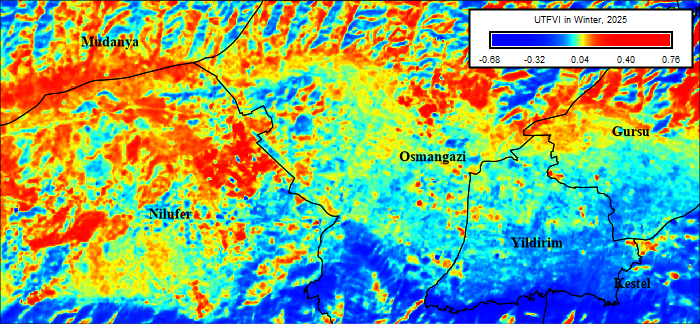

In [18]:
# Visualize the UTFVI map for winter and Bursa City's district
map_winter = gj.Map(use_region=True, width=700)
map_winter.d_rast(map="utfvi_winter_2025")
map_winter.d_vect(map="bursa_district",
                  color="black",
                  fill_color="none",
                  attribute_column="NAME",
                  width=1,
                  label_color="black",
                  label_size=10,
                  font="timesbd",
                  xref="center",
                  yref="center")
map_winter.d_legend(raster="utfvi_winter_2025",
                    title="UTFVI in Winter, 2025",
                    at=(85,90,70,96),
                    flags='b')
map_winter.show()

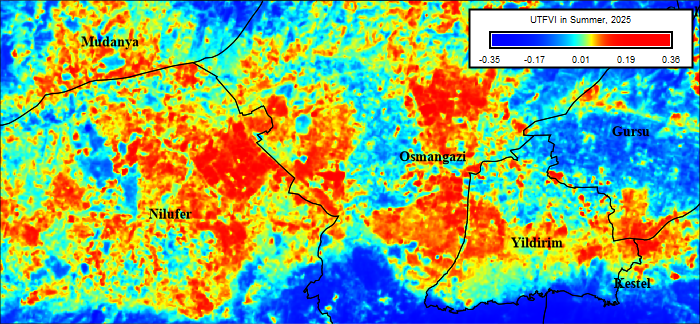

In [19]:
# Visualize the UTFVI map for summer and Bursa City's district
map_summer = gj.Map(use_region=True, width=700)
map_summer.d_rast(map="utfvi_summer_2025")
map_summer.d_vect(map="bursa_district",
                  color="black",
                  fill_color="none",
                  attribute_column="NAME",
                  width=1,
                  label_color="black",
                  label_size=10,
                  font="timesbd",
                  xref="center",
                  yref="center")
map_summer.d_legend(raster="utfvi_summer_2025",
                    title="UTFVI in Summer, 2025",
                    at=(85,90,70,96),
                    flags='b')
map_summer.show()

##### Urban Heat Island Phenomenon & Ecological Evaluation in Bursa City

Lastly, let’s conduct an ecological evaluation and examine the Urban Heat Island (UHI) phenomenon across the districts of Bursa City in both winter and summer seasons.

In [29]:
# Winter 2025
# UTFVI zonal stats
utfvi_stats_winter = gs.read_command("r.univar",
                                     flags="t",
                                     map="utfvi_winter_2025",
                                     zones="bursa_district",
                                     separator="comma")
df_utfvi_stats_winter = pd.read_csv(StringIO(utfvi_stats_winter))

# Get district names
attributes_winter = gs.read_command("v.db.select",
                             map="bursa_district",
                             columns="cat,NAME",
                             separator="comma",
                             format="csv")
df_names_winter = pd.read_csv(StringIO(attributes_winter))

# Merge stats with names
df_utfvi_final_winter = pd.merge(df_utfvi_stats_winter,
                           df_names_winter,
                           left_on="zone",  # From r.univar output
                           right_on="cat",  # From v.db.select
                           how="left")

# Summer 2025
# Get zonal statistics from GRASS
utfvi_stats_summer = gs.read_command("r.univar",
                        flags="t",
                        map="utfvi_summer_2025",
                        zones="bursa_district",
                        separator="comma")
df_utfvi_stats_summer = pd.read_csv(StringIO(utfvi_stats_summer))

# Get district names
attributes_summer = gs.read_command("v.db.select",
                             map="bursa_district",
                             columns="cat,NAME",
                             separator="comma",
                             format="csv")
df_names_summer = pd.read_csv(StringIO(attributes_summer))

# Merge stats with names
df_utfvi_final_summer = pd.merge(df_utfvi_stats_summer,
                           df_names_summer,
                           left_on="zone",  # From r.univar output
                           right_on="cat",  # From v.db.select
                           how="left")

In [66]:
# UTFVI table, UHI phenomenon and ecological evaluation for winter
def uhi_phenomenon(value):
    if value < 0:
        return "None"
    elif value <= 0.005:
        return "Weak"
    elif value <= 0.010:
        return "Middle"
    elif value <= 0.015:
        return "Strong"
    elif value <= 0.020:
        return "Stronger"
    else:
        return "Strongest"
    
def eco_eval(value):
    if value < 0:
        return "Excellent"
    elif value <= 0.005:
        return "Good"
    elif value <= 0.010:
        return "Normal"
    elif value <= 0.015:
        return "Bad"
    elif value <= 0.020:
        return "Worse"
    else:
        return "Worst"

df_utfvi_final_winter_renamed = df_utfvi_final_winter[["cat", "NAME", "mean"]].rename(
    columns={
        "cat": "ID",
        "NAME": "District",
        "mean": "Avg_UTFVI_Winter_2025"
    }
)

df_utfvi_final_winter_renamed["UHI_Phenomenon"] = df_utfvi_final_winter_renamed["Avg_UTFVI_Winter_2025"].apply(uhi_phenomenon)
df_utfvi_final_winter_renamed["Ecological_Evaluation"] = df_utfvi_final_winter_renamed["Avg_UTFVI_Winter_2025"].apply(eco_eval)

# UTFVI table, UHI phenomenon and ecological evaluation for summer
df_utfvi_final_summer_renamed = df_utfvi_final_summer[["cat", "NAME", "mean"]].rename(
    columns={
        "cat": "ID",
        "NAME": "District",
        "mean": "Avg_UTFVI_Summer_2025"
    }
)

df_utfvi_final_summer_renamed["UHI_Phenomenon"] = df_utfvi_final_summer_renamed["Avg_UTFVI_Summer_2025"].apply(uhi_phenomenon)
df_utfvi_final_summer_renamed["Ecological_Evaluation"] = df_utfvi_final_summer_renamed["Avg_UTFVI_Summer_2025"].apply(eco_eval)

In [68]:
print(df_utfvi_final_winter_renamed)
print(df_utfvi_final_summer_renamed)

   ID   District  Avg_UTFVI_Winter_2025 UHI_Phenomenon Ecological_Evaluation
0   1   Yildirim              -0.078281           None             Excellent
1   2      Gursu               0.019664       Stronger                 Worse
2   3     Gemlik              -0.143618           None             Excellent
3   4  Osmangazi              -0.006717           None             Excellent
4   5    Mudanya               0.061318      Strongest                 Worst
5   6    Nilufer               0.033635      Strongest                 Worst
6   7     Kestel              -0.183743           None             Excellent
   ID   District  Avg_UTFVI_Summer_2025 UHI_Phenomenon Ecological_Evaluation
0   1   Yildirim               0.015006       Stronger                 Worse
1   2      Gursu              -0.045822           None             Excellent
2   3     Gemlik              -0.178302           None             Excellent
3   4  Osmangazi              -0.006957           None             Excellent

C:\Users\DELL\AppData\Local\Temp\ipykernel_10056\4128777149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_utfvi_final_winter_renamed,


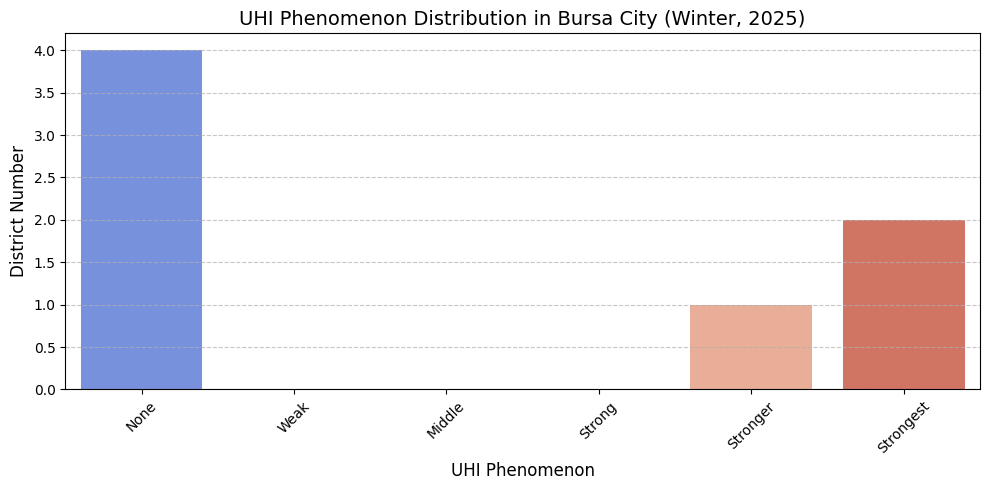

In [72]:
# Bar chart for winter
plt.figure(figsize=(10, 5))
sns.countplot(data=df_utfvi_final_winter_renamed, 
              x="UHI_Phenomenon", 
              order=["None", "Weak", "Middle", "Strong", "Stronger", "Strongest"],
              palette="coolwarm")

plt.title("UHI Phenomenon Distribution in Bursa City (Winter, 2025)", fontsize=14)
plt.xlabel("UHI Phenomenon", fontsize=12)
plt.ylabel("District Number", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10056\4292637396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_utfvi_final_summer_renamed,


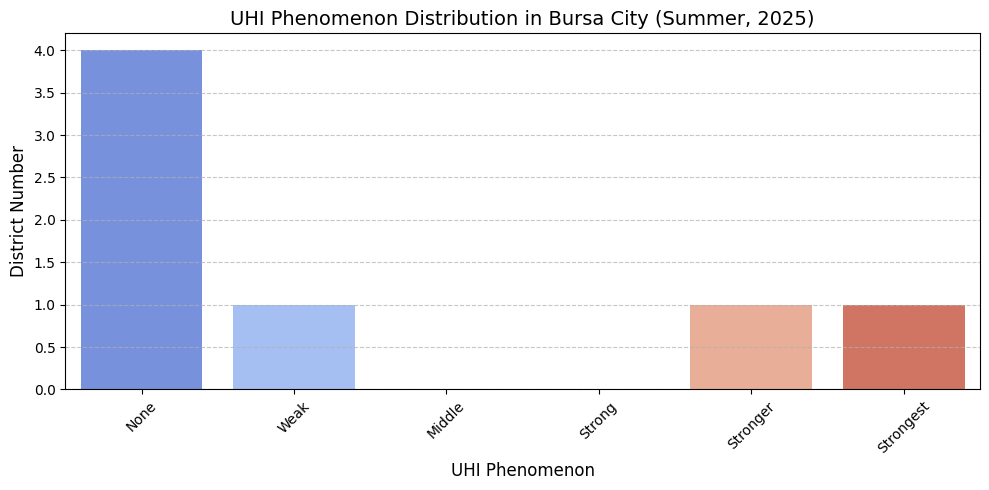

In [73]:
# Bar chart for summer
plt.figure(figsize=(10, 5))
sns.countplot(data=df_utfvi_final_summer_renamed, 
              x="UHI_Phenomenon", 
              order=["None", "Weak", "Middle", "Strong", "Stronger", "Strongest"],
              palette="coolwarm")

plt.title("UHI Phenomenon Distribution in Bursa City (Summer, 2025)", fontsize=14)
plt.xlabel("UHI Phenomenon", fontsize=12)
plt.ylabel("District Number", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Comparison of Ecological Evaluation Between Winter and Summer

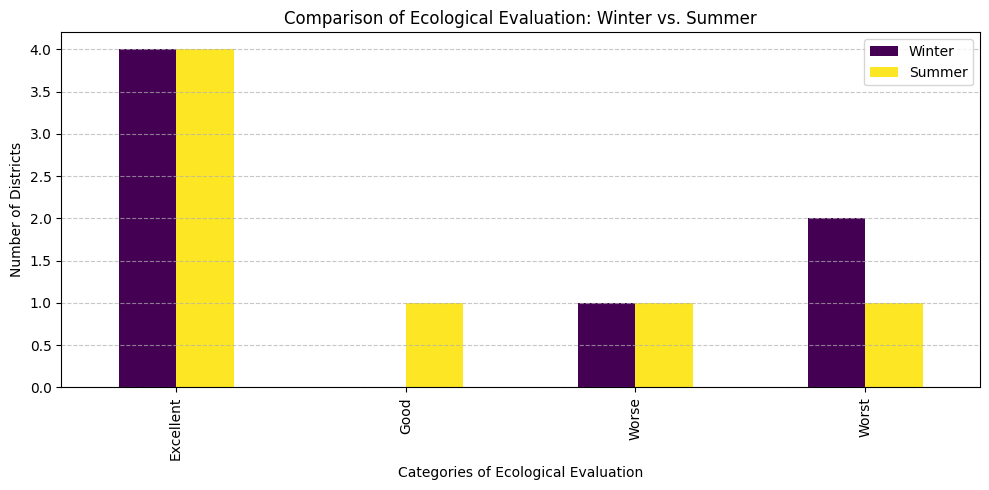

In [82]:
df_eco_compare = pd.merge(df_utfvi_final_winter_renamed[["District", "Ecological_Evaluation"]],
                          df_utfvi_final_summer_renamed[["District", "Ecological_Evaluation"]],
                          on="District",
                          suffixes=("_Winter", "_Summer"))

eco_counts = pd.DataFrame({
    "Winter": df_eco_compare["Ecological_Evaluation_Winter"].value_counts(),
    "Summer": df_eco_compare["Ecological_Evaluation_Summer"].value_counts()
}).fillna(0)

eco_counts.plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Comparison of Ecological Evaluation: Winter vs. Summer")
plt.xlabel("Categories of Ecological Evaluation")
plt.ylabel("Number of Districts")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Correlation between Land Surface Temperature and UTFVI

This additional analysis aims to determine whether there is a strong correlation between Land Surface Temperature (LST) and the Urban Thermal Field Variance Index (UTFVI).

In [78]:
# Correlation between UHI and UTFVI in winter
df_corr_winter = pd.merge(df_lst_final_winter_renamed,
                   df_utfvi_final_winter_renamed[["ID", "Avg_UTFVI_Winter_2025"]],
                   on="ID")

corr_matrix_winter = df_corr_winter[["Avg_LST_Winter_2025", "Avg_UTFVI_Winter_2025"]].corr()

# Correlation between UHI and UTFVI in summer
df_corr_summer = pd.merge(df_lst_final_summer_renamed,
                   df_utfvi_final_summer_renamed[["ID", "Avg_UTFVI_Summer_2025"]],
                   on="ID")

corr_matrix_summer = df_corr_summer[["Avg_LST_Summer_2025", "Avg_UTFVI_Summer_2025"]].corr()

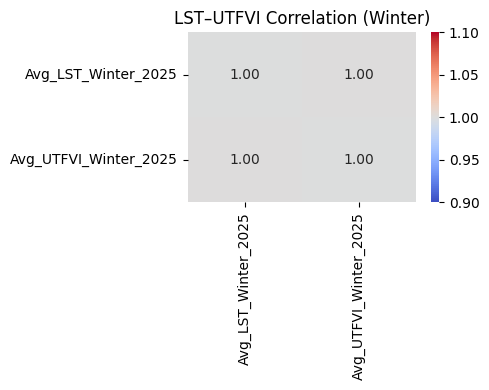

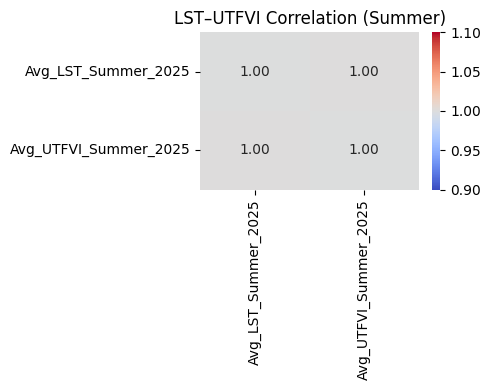

In [81]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_winter, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("LST–UTFVI Correlation (Winter)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_summer, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("LST–UTFVI Correlation (Summer)")
plt.tight_layout()
plt.show()

Land Surface Temperature (LST) and the Urban Thermal Field Variance Index (UTFVI) exhibit a strong correlation. The Pearson correlation coefficient between the two variables is 1, indicating a perfectly positive and very strong linear relationship. This result is expected, as UTFVI is directly calculated based on LST values, making the correlation inherently perfect and proportional.